In [37]:
# Importación de librerías necesarias
import os
import time
import numpy as np

from pathlib import Path
import pandas as pd  # Manipulación y análisis de datos
import numpy as np  # Operaciones numéricas y arrays
import matplotlib.pyplot as plt  # Visualización básica
import seaborn as sns  # Visualización estadística avanzada
from scipy import stats  # Funciones estadísticas
from scipy.stats import skew, kurtosis  # Métricas de distribución
import warnings  # Manejo de advertencias
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Configuración de estilos y opciones
warnings.filterwarnings('ignore')  # Ignorar advertencias para limpieza visual
sns.set_style('whitegrid')  # Estilo de gráficas con cuadrícula blanca
plt.rcParams['figure.figsize'] = (12, 6)  # Tamaño por defecto de figuras
plt.rcParams['font.size'] = 10  # Tamaño de fuente
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.precision', 4)  # Precisión decimal en display

#Crear directorios para guardar modelos, predicciones y resultados
os.makedirs("models", exist_ok=True)
os.makedirs("predictions", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Importaciones adicionales para deep learning y búsqueda de hiperparámetros
import time
import itertools
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0, VGG16, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Keras Tuner para búsqueda de hiperparámetros (GridSearch)
try:
    import keras_tuner as kt
    KERAS_TUNER_AVAILABLE = True
    print("keras-tuner disponible.")
except ImportError:
    KERAS_TUNER_AVAILABLE = False
    print("keras-tuner no instalado. Instalar con: pip install keras-tuner")
    print("Las celdas de GridSearch usarán busqueda manual como fallback.")

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs disponibles: {tf.config.list_physical_devices('GPU')}") 

keras-tuner no instalado. Instalar con: pip install keras-tuner
Las celdas de GridSearch usarán busqueda manual como fallback.
TensorFlow: 2.21.0
GPUs disponibles: []


In [59]:
#Leer archivo con datos originales
df = pd.read_csv("inferencia.csv")

#Copia de dataset
df_clean = df.copy()

logmass_mean = df_clean["LogMass"].mean()
logmass_std = df_clean["LogMass"].std()

def inverse_logmass_scaled(y_scaled):
    return y_scaled * logmass_std + logmass_mean

#REEMPLAZAR PLACEHOLDERS POR NaN
placeholder_map = {
    "C": [-999],
    "A": [-999],
    "S": [-999, -102.97, -118.68],
    "nsa_sersic_mass": [-9999],
    "nsa_sersic_ba": [-9999],
    "nsa_sersic_n": [-9999]
}

for col, values in placeholder_map.items():
    df_clean[col] = df_clean[col].replace(values, np.nan)

#DEFINICIÓN DE VARIABLES
# Variables con asimetría fuerte o potencialmente problemáticas
skewed_cols = [
    "nsa_sersic_mass",
    "PETRO_TH90",
    "modelMag_r",
    "C",
    "A",
    "S"
]

# Variables que ya están bastante estabilizadas o en log
normal_cols = [
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re"
]

# Coordenadas
coordinate_cols = [
    "objra",
    "objdec"
]

#Orden original de las columnas
final_columns = [
    "objra",
    "objdec",
    "C",
    "A",
    "S",
    "nsa_sersic_mass",
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "PETRO_TH90",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re",
    "modelMag_r"
]

# Filtrar solo columnas existentes
skewed_cols = [c for c in skewed_cols if c in df_clean.columns]
normal_cols = [c for c in normal_cols if c in df_clean.columns]
coordinate_cols = [c for c in coordinate_cols if c in df_clean.columns]

# Para variables sesgadas: imputación + Yeo-Johnson + escalado
skewed_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler())
])

# Para variables ya estables: imputación + escalado
normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Para coordenadas: imputación + escalado
coordinate_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# COLUMN TRANSFORMER
preprocessor = ColumnTransformer([
    ("skewed_vars", skewed_pipeline, skewed_cols),
    ("normal_vars", normal_pipeline, normal_cols),
    ("coordinates", coordinate_pipeline, coordinate_cols)
], remainder="drop")

# AJUSTAR Y TRANSFORMAR
X_transformed = preprocessor.fit_transform(df_clean)

transformer_columns = skewed_cols + normal_cols + coordinate_cols

df_transformed_numeric = pd.DataFrame(
    X_transformed,
    columns=transformer_columns,
    index=df_clean.index
)

# Reordenar columnas al formato deseado
df_transformed_numeric = df_transformed_numeric[final_columns]

# Conservar columna name como identificador de cada galaxia
df_transformed = pd.concat(
    [
        df_clean[["name"]],
        df_transformed_numeric
    ],
    axis=1
)

print("Shape original:", df_clean.shape)
print("Shape transformado:", df_transformed.shape)
df_transformed.head()

Shape original: (10126, 17)
Shape transformado: (10126, 17)


,name,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
0,manga-10001-12701,-0.6523,1.6126,-1.3471,-0.0074,-0.0309,-0.9490,-0.9403,-1.2084,-1.2748,-0.9719,-1.1521,-1.3084,0.8322,0.6072,2.0522,0.8076
1,manga-10001-12702,-0.6482,1.6060,-0.6744,-0.3508,-0.2956,-0.6325,-0.6049,-0.4241,-0.9179,0.1545,-1.0850,-0.7010,0.5290,0.1930,2.0572,1.0683
2,manga-10001-12703,-0.6176,1.5844,-0.0944,-0.2080,0.1655,-0.0753,-0.0354,-1.7963,-0.5420,-0.0049,-0.7376,-0.1556,0.7577,0.7587,0.6348,0.1766
3,manga-10001-12704,-0.6442,1.6170,0.1224,0.0694,0.7020,-0.7591,-0.7380,-2.0492,-1.2099,1.4307,-0.7461,-0.7883,-0.0408,0.3075,0.7127,-0.8335
4,manga-10001-12705,-0.6080,1.6044,-0.6729,-0.1478,-0.1510,-0.1074,-0.0674,-0.5909,-1.0158,-0.3170,-1.1710,-1.2657,1.0966,1.0637,1.9645,0.1993


In [39]:
# CONSTRUCCIÓN DEL DATASET SUPERVISADO PARA LogMass
# Relación imagen <-> variable objetivo mediante 'name'


target_col = "LogMass"

df_logmass = df_transformed[["name", target_col]].copy()
df_logmass = df_logmass.dropna(subset=[target_col])

# Ajustar ruta según entorno local
image_dir = Path(r"/Users/gustavomorales/Desktop/ITESM_MNA/Proyecto integrador/Imagenes")

df_logmass["image_path"]   = df_logmass["name"].apply(lambda x: image_dir / f"{x}.jpg")
df_logmass["image_exists"] = df_logmass["image_path"].apply(lambda p: p.exists())

print("Total registros:      ", len(df_logmass))
print("Imagenes encontradas: ", df_logmass["image_exists"].sum())
print("Imagenes faltantes:   ", (~df_logmass["image_exists"]).sum())

df_logmass = df_logmass[df_logmass["image_exists"]].copy()
df_logmass = df_logmass[["name", target_col, "image_path"]].copy()


# TRAIN / VALIDATION / TEST SPLIT
# 70% entrenamiento | 15% validacion | 15% prueba
# Misma semilla que Avance 3 para comparabilidad

train_df, temp_df = train_test_split(df_logmass, test_size=0.30, random_state=42)
val_df,   test_df = train_test_split(temp_df,    test_size=0.50, random_state=42)

print("\nShape dataset LogMass:", df_logmass.shape)
print("Train:     ", train_df.shape)
print("Validation:", val_df.shape)
print("Test:      ", test_df.shape)

Total registros:       10126
Imagenes encontradas:  10126
Imagenes faltantes:    0

Shape dataset LogMass: (10126, 3)
Train:      (7088, 3)
Validation: (1519, 3)
Test:       (1519, 3)


In [40]:
# PARAMETROS GLOBALES Y FUNCIONES DE CARGA DE IMAGENES

IMG_SIZE   = (224, 224)   # Compatible con todos los modelos
BATCH_SIZE = 16           # Consistente con Avance 3

def load_image_regression(image_path, target):
    """
    Carga, decodifica, redimensiona y normaliza una imagen JPEG.

    Parameters
    ----------
    image_path : tf.string
    target     : tf.float32  valor objetivo normalizado (LogMass)

    Returns
    -------
    image  : tf.Tensor shape (224, 224, 3) float32, valores en [0, 1]
    target : tf.float32
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, target


def create_dataset(dataframe, shuffle=True):
    """
    Construye un tf.data.Dataset desde un DataFrame con rutas de imagenes.

    Parameters
    ----------
    dataframe : pd.DataFrame  columnas 'image_path' y target_col
    shuffle   : bool

    Returns
    -------
    dataset : tf.data.Dataset
    """
    image_paths = dataframe["image_path"].astype(str).values
    targets     = dataframe[target_col].astype("float32").values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    dataset = dataset.map(load_image_regression, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=42)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds   = create_dataset(val_df,   shuffle=False)
test_ds  = create_dataset(test_df,  shuffle=False)

print("Datasets creados exitosamente.")

Datasets creados exitosamente.


In [41]:
# Heredada del Avance 3; calcula MAE, RMSE, R2, Scatter, Bias

def evaluate_regression_complete(y_true, y_pred, variable_name='LogMass'):
    """
    Evalua un modelo de regresion con metricas astronomicas completas.

    Parameters
    ----------
    y_true        : array-like  valores reales
    y_pred        : array-like  valores predichos
    variable_name : str

    Returns
    -------
    dict : R2, MAE, RMSE, MSE, Scatter, Bias, RMSE_MAE_ratio, Categoria
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae      = mean_absolute_error(y_true, y_pred)
    mse      = mean_squared_error(y_true, y_pred)
    rmse     = np.sqrt(mse)
    r2       = r2_score(y_true, y_pred)
    residuals = y_true - y_pred
    scatter   = np.std(residuals)
    bias      = np.mean(residuals)
    rmse_mae  = rmse / mae if mae > 0 else np.inf

    print(f"Metricas de Regresion para {variable_name}:")
    print(f"  R2 Score:        {r2:.4f}  ({r2*100:.2f}% varianza explicada)")
    print(f"  MAE:             {mae:.4f} dex")
    print(f"  RMSE:            {rmse:.4f} dex")
    print(f"  MSE:             {mse:.4f} dex2")
    print(f"  Scatter (sigma): {scatter:.4f} dex")
    print(f"  Bias:            {bias:+.4f} dex")
    print(f"  RMSE/MAE ratio:  {rmse_mae:.2f}")
    print()

    mae_f = 10 ** mae; scat_f = 10 ** scatter
    print("Interpretacion fisica (escala lineal):")
    print(f"  Error promedio (MAE):   {mae_f:.2f}x")
    print(f"  Dispersion tipica:      +/-{scat_f:.2f}x")
    print(f"  Rango de error tipico:  [{1/mae_f:.2f}x, {mae_f:.2f}x]")
    if   abs(bias) < 0.05: print("  Sin sesgo sistematico significativo (bias ~ 0)")
    elif bias > 0:         print(f"  Sesgo positivo: modelo subestima ({bias:+.4f} dex)")
    else:                  print(f"  Sesgo negativo: modelo sobreestima ({bias:+.4f} dex)")
    print()

    if   r2 >= 0.90: cat, desc = "EXCELENTE", "Modelo de alta precision"
    elif r2 >= 0.80: cat, desc = "MUY BUENO", "Baseline fuerte"
    elif r2 >= 0.70: cat, desc = "BUENO",     "Desempeno aceptable"
    elif r2 >= 0.50: cat, desc = "REGULAR",   "Mejora requerida"
    else:            cat, desc = "INACEPTABLE","Modelo no viable"

    print(f"Evaluacion cualitativa: {cat} - {desc}")
    print()
    print("Diagnostico de errores:")
    if   rmse_mae > 2.0: print(f"  ADVERTENCIA: RMSE/MAE={rmse_mae:.2f} - outliers severos")
    elif rmse_mae > 1.5: print(f"  NOTA: RMSE/MAE={rmse_mae:.2f} - algunos errores grandes")
    else:                print(f"  RMSE/MAE={rmse_mae:.2f} - distribucion normal, sin outliers extremos")

    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MSE': mse,
            'Scatter': scatter, 'Bias': bias,
            'RMSE_MAE_ratio': rmse_mae, 'Categoria': cat}



# Funciones auxiliares de entrenamiento y visualizacion


def get_predictions(model, dataset):
    """Obtiene predicciones y etiquetas reales de un tf.data.Dataset."""
    y_true_list, y_pred_list = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true_list.extend(labels.numpy())
        y_pred_list.extend(preds.flatten())
    return np.array(y_true_list), np.array(y_pred_list)


def train_model(model, train_ds, val_ds, epochs=30, patience=7):
    """
    Entrena un modelo Keras con EarlyStopping y ReduceLROnPlateau.

    Parameters
    ----------
    model    : tf.keras.Model  (ya compilado)
    train_ds, val_ds : tf.data.Dataset
    epochs   : int
    patience : int  paciencia EarlyStopping

    Returns
    -------
    history : tf.keras.callbacks.History
    elapsed : float  segundos totales
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]
    start   = time.time()
    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=epochs, callbacks=callbacks, verbose=1)
    elapsed = time.time() - start
    print(f"\nTiempo de entrenamiento: {elapsed:.1f}s ({elapsed/60:.1f} min)")
    return history, elapsed


def plot_training_curves(history, model_name):
    """Grafica curvas de perdida (MSE) y MAE de entrenamiento/validacion."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss', lw=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',   lw=2)
    axes[0].set_title(f'Curva de Perdida (MSE) - {model_name}')
    axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('MSE')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['mae'],     label='Train MAE', lw=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE',   lw=2)
    axes[1].set_title(f'Curva de MAE - {model_name}')
    axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('MAE (dex)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_combined_history(h1, h2, model_name):
    """
    Grafica curvas de dos fases de entrenamiento (feature extraction + fine-tuning)
    unificadas con linea vertical separadora.
    Retorna el total de epocas ejecutadas.
    """
    sep   = len(h1.history['loss'])
    loss  = h1.history['loss']     + h2.history['loss']
    vloss = h1.history['val_loss'] + h2.history['val_loss']
    mae   = h1.history['mae']      + h2.history['mae']
    vmae  = h1.history['val_mae']  + h2.history['val_mae']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, y, yv, ylabel, title in [
        (axes[0], loss, vloss, 'MSE',       f'Curva de Perdida - {model_name}'),
        (axes[1], mae,  vmae,  'MAE (dex)', f'Curva de MAE - {model_name}')
    ]:
        ax.plot(y,  label='Train', lw=2)
        ax.plot(yv, label='Val',   lw=2)
        ax.axvline(x=sep, color='red', ls='--', alpha=0.7, label='Inicio Fine-Tuning')
        ax.set_title(title); ax.set_xlabel('Epoca'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return len(loss)


# Registro global de resultados
results_registry = {}

print("Funciones utilitarias definidas correctamente.")

Funciones utilitarias definidas correctamente.


# Modelo 0 Baseline

In [42]:
from tensorflow.keras import layers, models

# DATA AUGMENTATION

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
])

model_logmass0 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="linear")
])

model_logmass0.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
model_logmass0.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_logmass0 = model_logmass0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)
time_m0 = time.time() - start_time
model_logmass0.save("models/M0_CNN_Baseline.keras")

Epoch 1/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 47s 98ms/step - loss: 0.7085 - mae: 0.6720 - val_loss: 0.3995 - val_mae: 0.4893 - learning_rate: 0.0010
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - loss: 0.4037 - mae: 0.4878 - val_loss: 0.4654 - val_mae: 0.5405 - learning_rate: 0.0010
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - loss: 0.3690 - mae: 0.4682 - val_loss: 0.3109 - val_mae: 0.4195 - learning_rate: 0.0010
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 46s 100ms/step - loss: 0.3491 - mae: 0.4538 - val_loss: 0.2931 - val_mae: 0.4021 - learning_rate: 0.0010
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 46s 100ms/step - loss: 0.3384 - mae: 0.4434 - val_loss: 0.2991 - val_mae: 0.4070 - learning_rate: 0.0010
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.3403 - mae: 0.4403
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
443/443 ━━━━━━━━━━━━━━━━━━━━ 46s 100ms/step - loss: 0.3326 - mae: 0.4400 - val_loss: 0.3129 - val_mae: 0.4231 - learni

In [44]:
print("\nEVALUACION EN TEST SET - Modelo 0\n")

y_test_m0, y_pred_m0 = get_predictions(model_logmass0, test_ds)

metrics_m0 = evaluate_regression_complete(
    y_test_m0, 
    y_pred_m0, 
    "LogMass"
)

metrics_m0.update({
    'Params': model_logmass0.count_params(),
    'Train_Time_s': time_m0,
    'Epochs_Run': len(history_logmass0.history['loss'])
})

results_registry["M0_Baseline_CNN"] = metrics_m0

print("\nMetricas CNN Baseline:")
print(f"  R2:   {metrics_m0['R2']:.4f}")
print(f"  MAE:  {metrics_m0['MAE']:.4f} dex")
print(f"  RMSE: {metrics_m0['RMSE']:.4f} dex")


EVALUACION EN TEST SET - Modelo 0

Metricas de Regresion para LogMass:
  R2 Score:        0.7642  (76.42% varianza explicada)
  MAE:             0.3574 dex
  RMSE:            0.4763 dex
  MSE:             0.2268 dex2
  Scatter (sigma): 0.4761 dex
  Bias:            -0.0121 dex
  RMSE/MAE ratio:  1.33

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   2.28x
  Dispersion tipica:      +/-2.99x
  Rango de error tipico:  [0.44x, 2.28x]
  Sin sesgo sistematico significativo (bias ~ 0)

Evaluacion cualitativa: BUENO - Desempeno aceptable

Diagnostico de errores:
  RMSE/MAE=1.33 - distribucion normal, sin outliers extremos

Metricas CNN Baseline:
  R2:   0.7642
  MAE:  0.3574 dex
  RMSE: 0.4763 dex


In [ ]:
model_logmass0.save("models/M0_CNN_Baseline.keras")

np.save("predictions/M0_y_test.npy", y_test_m0)
np.save("predictions/M0_y_pred_test.npy", y_pred_m0)

y_test_m0_real = inverse_logmass_scaled(y_test_m0)
y_pred_m0_real = inverse_logmass_scaled(y_pred_m0.flatten())

y_val_m0, y_pred_val_m0 = get_predictions(model_logmass0, val_ds)
np.save("predictions/M0_y_val.npy", y_val_m0)
np.save("predictions/M0_y_pred_val.npy", y_pred_val_m0)

___
# Modelo 1. CNN con mejores hiperparametros

Mejores parametros (busqueda manual): {'dropout_rate': 0.4, 'dense_units': 256, 'learning_rate': 0.001}
Mejor val_mae: 0.4826

In [ ]:
# MODELO 1: CNN Custom Baseline con arquitectura parametrizada

data_aug_m1 = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
], name="aug_m1")

def build_cnn_baseline(dropout_rate=0.4, dense_units=128, learning_rate=1e-3):

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_aug_m1(inputs)

    x = layers.Conv2D(32,  (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64,  (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs, outputs, name="CNN_Baseline_Tuned")
    model.compile(optimizer=Adam(learning_rate), loss='mse', metrics=['mae'])
    return model


# Version con los mejores hiperparametros encontrados con Gridsearch en la actividad anterior

best_params_m1 = {
    "dropout_rate": 0.4,
    "dense_units": 256,
    "learning_rate": 0.001
}

model_logmass1 = build_cnn_baseline(**best_params_m1)
model_logmass1.summary()

Model: "CNN_Baseline_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_m1 (Sequential)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,529 (494.25 KB)

 Trainable params: 126,529 (494.25 KB)

 Non-trainable params: 0 (0.00 B)

ENTRENAMIENTO FINAL: CNN Baseline con HPs optimizados
Epoch 1/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 45s 97ms/step - loss: 0.9027 - mae: 0.7879 - val_loss: 0.7512 - val_mae: 0.7132 - learning_rate: 0.0010
Epoch 2/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - loss: 0.6254 - mae: 0.6203 - val_loss: 0.6149 - val_mae: 0.6116 - learning_rate: 0.0010
Epoch 3/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - loss: 0.5592 - mae: 0.5812 - val_loss: 0.5064 - val_mae: 0.5589 - learning_rate: 0.0010
Epoch 4/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - loss: 0.5428 - mae: 0.5757 - val_loss: 0.6102 - val_mae: 0.6339 - learning_rate: 0.0010
Epoch 5/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - loss: 0.5333 - mae: 0.5634 - val_loss: 0.4895 - val_mae: 0.5481 - learning_rate: 0.0010
Epoch 6/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - loss: 0.4964 - mae: 0.5426 - val_loss: 0.5137 - val_mae: 0.5462 - learning_rate: 0.0010
Epoch 7/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - loss: 0.4818 - mae: 0.5372

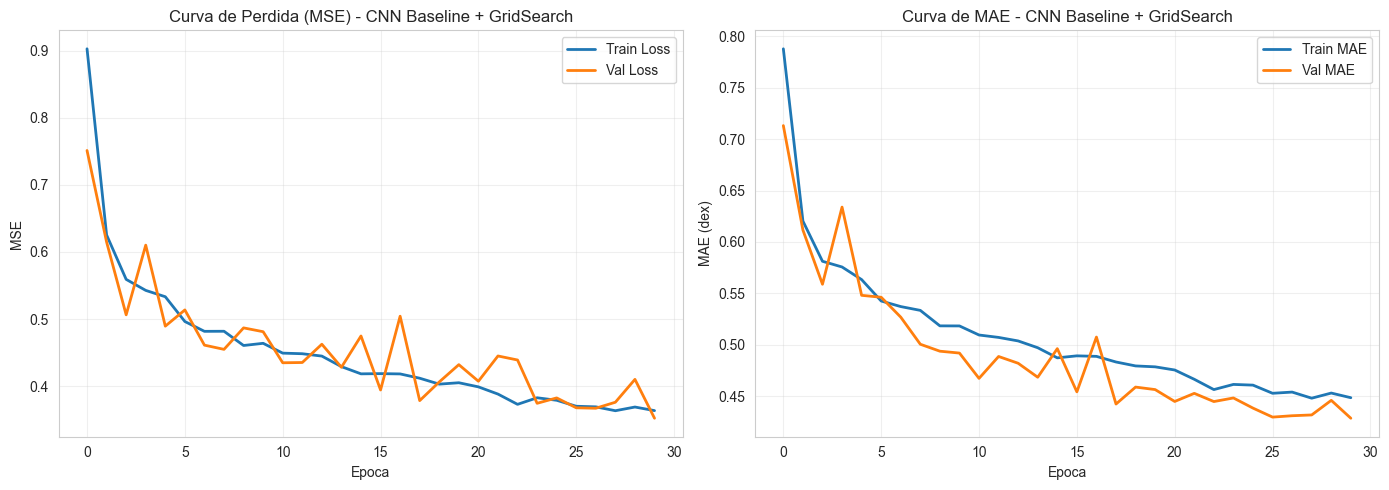

In [ ]:
# Entrenamiento final - Modelo 1 con hiperparametros optimos
print("ENTRENAMIENTO FINAL: CNN Baseline con HPs optimizados")

start_time = time.time()
history_logmass1, time_m1 = train_model(model_logmass1, train_ds, val_ds, epochs=30, patience=7)
plot_training_curves(history_logmass1, "CNN Baseline + GridSearch")

time_m1 = time.time() - start_time
model_logmass1.save("models/M1_CNN_Tuned.keras")

In [ ]:
print("\nEVALUACION EN TEST SET - Modelo 1\n")

y_test_m1, y_pred_m1 = get_predictions(model_logmass1, test_ds)

metrics_m1 = evaluate_regression_complete(
    y_test_m1, 
    y_pred_m1, 
    "LogMass"
)

metrics_m1.update({
    'Params': model_logmass1.count_params(),
    'Train_Time_s': time_m1,
    'Epochs_Run': len(history_logmass1.history['loss'])
})

results_registry["M1_Baseline_CNN"] = metrics_m1

print("\nMetricas CNN Tuned:")
print(f"  R2:   {metrics_m1['R2']:.4f}")
print(f"  MAE:  {metrics_m1['MAE']:.4f} dex")
print(f"  RMSE: {metrics_m1['RMSE']:.4f} dex")


EVALUACION EN TEST SET - Modelo 1

Metricas de Regresion para LogMass:
  R2 Score:        0.6558  (65.58% varianza explicada)
  MAE:             0.4300 dex
  RMSE:            0.5753 dex
  MSE:             0.3310 dex2
  Scatter (sigma): 0.5681 dex
  Bias:            -0.0911 dex
  RMSE/MAE ratio:  1.34

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   2.69x
  Dispersion tipica:      +/-3.70x
  Rango de error tipico:  [0.37x, 2.69x]
  Sesgo negativo: modelo sobreestima (-0.0911 dex)

Evaluacion cualitativa: REGULAR - Mejora requerida

Diagnostico de errores:
  RMSE/MAE=1.34 - distribucion normal, sin outliers extremos

Metricas CNN Tuned:
  R2:   0.6558
  MAE:  0.4300 dex
  RMSE: 0.5753 dex


In [58]:
model_logmass1.save("models/M1_CNN_Tuned.keras")

np.save("predictions/M1_y_test.npy", y_test_m1)
np.save("predictions/M1_y_pred_test.npy", y_pred_m1)

y_val_m1, y_pred_val_m1 = get_predictions(model_logmass1, val_ds)
np.save("predictions/M1_y_val.npy", y_val_m1)
np.save("predictions/M1_y_pred_val.npy", y_pred_val_m1)

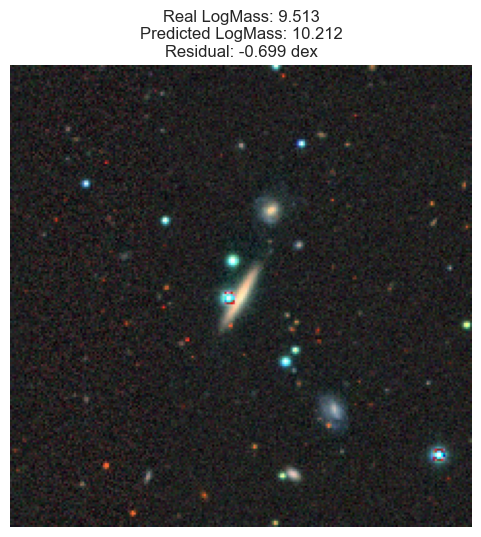

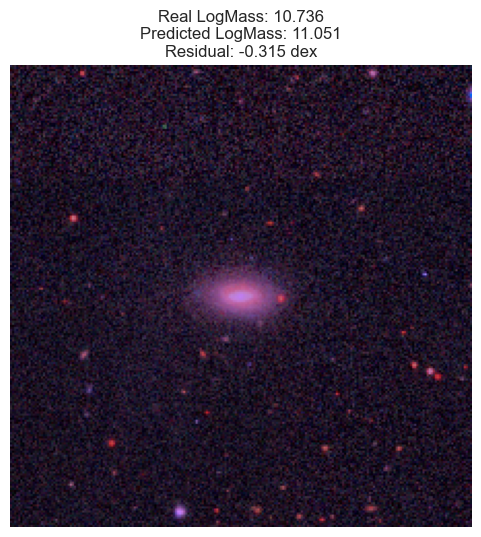

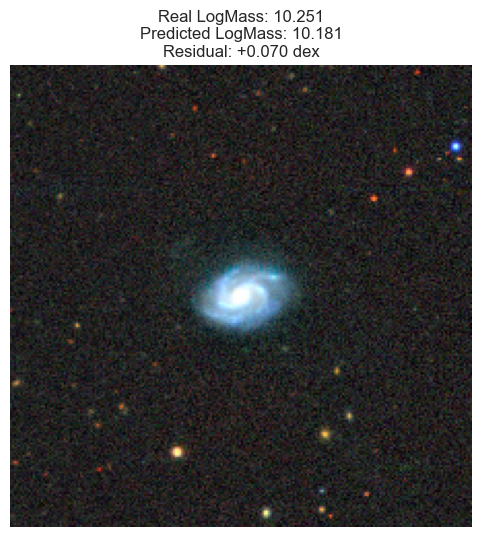

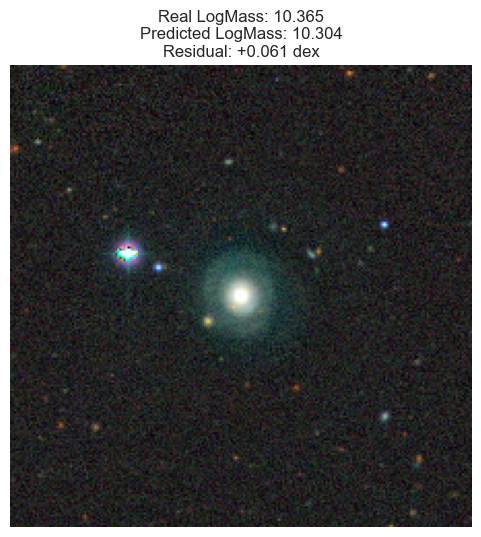

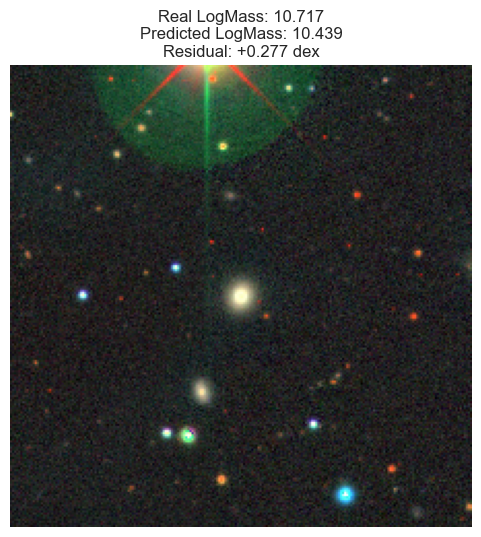

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

for i in range(5):

    # SELECCIONAR UNA MUESTRA ALEATORIA
    sample_row = test_df.sample(1).iloc[0]
    img_path = sample_row["image_path"]

    # Valor real ESCALADO
    real_logmass_scaled = sample_row[target_col]

    # Convertir a LogMass REAL
    real_logmass = inverse_logmass_scaled(real_logmass_scaled)

    # CARGAR Y PREPROCESAR IMAGEN
    img = image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)
    img_array = img_array / 255.0

    # Agregar dimensión batch
    img_input = np.expand_dims(img_array, axis=0)

    # PREDICCIÓN DEL MODELO (ESCALADA)
    pred_logmass_scaled = model_logmass0.predict(
        img_input,
        verbose=0
    )[0][0]

    # Convertir predicción a escala real
    pred_logmass = inverse_logmass_scaled(pred_logmass_scaled)

    # Error físico
    error_dex = real_logmass - pred_logmass

    # VISUALIZACIÓN
    plt.figure(figsize=(6,6))
    plt.imshow(img_array)

    plt.title(
        f"Real LogMass: {real_logmass:.3f}\n"
        f"Predicted LogMass: {pred_logmass:.3f}\n"
        f"Residual: {error_dex:+.3f} dex"
    )

    plt.axis("off")
    plt.show()